In [127]:
import sisl
import numpy as np
from ase.visualize import view
import matplotlib.pyplot as plt

In [128]:
BOND = 1.42
N0 = 4
N1 = 6
ETA = 1e-3
NK1 = 250

In [129]:
Rz = lambda theta: np.array([[np.cos(theta), -np.sin(theta), 0],
                              [np.sin(theta), np.cos(theta), 0],
                              [0,0,1]])
def all_armchair(bond):
    theta = np.pi*(2/3) # angle in hexagon lattice
    phi = theta/2 # half angle
    b = bond*np.sqrt(3)/2 # inner-radii of hexagon
    vac = 20
    gr = sisl.geom.graphene_flake(0, bond=bond, vacuum=vac) # based on flake structure for conveniece
    gr = gr.translate(-gr.center()) # center structure to origo
    gr = gr.rotate([phi/2, [0,0,1]], rad=True, what="xyz") # rotate by 30 degrees (or pi/6 rad)
    gr = gr.translate([2*b, 0, 0]) # translate twice by inner radii to make edges follow unit cell vectors
    
    # define and set the new unit vectors
    base = np.array([3*bond, 0, 0]) 
    armchair_cell = np.array([Rz(-phi/2)@base, # rotate vector A by -30 degrees (clockwise)
                            Rz(phi/2)@base, # rotate vector B by 30 degrees (counter-clockwise)
                            [0,0,vac]]) # no change for C vector
    
    gr.set_lattice(armchair_cell) 
    
    
    
    # sort atom by keys -- right-most / last key (the x-coord) is most 'dominant' and uses others as tie breakers 
    # this method only sorts correctly if we use fractional coordiantes
    fracxyz = gr.xyz @ np.linalg.inv(gr.cell)
    
    exponent = 6
    tol = 10**(-exponent)
    fracxyz = np.where(np.isclose(fracxyz, 0, atol=tol), 0.0, fracxyz.round(exponent)) 
    sort_idx = np.lexsort([fracxyz[:, 2], fracxyz[:, 1], fracxyz[:, 0]])
    gr = gr.sub(sort_idx)
    gr.set_nsc([3,3,1])
    return gr


def plot_structure_NN(geom, idx=0):
    if idx >= geom.na:
        print(f'idx {idx} is too large for structure with {geom.na} atoms. Setting idx = {geom.na-1}')
        idx = geom.na - 1
        
    xyz = geom.xyz
    dist = np.linalg.norm(xyz[idx] - xyz, axis=1)
    dist = dist.round(10)


    NN_mask = (dist <= BOND) & (dist > 0.0)
    style = [
        {'atoms': idx, 'color': 'red', 'name':'Investigate'}, # color atom of index 'idx'
        {'atoms': NN_mask, 'color': 'blue', 'name':'NN'}, # color the NN atoms
    ]
    return geom.plot(axes='xy', atoms_style=style)

In [130]:
gr = all_armchair(bond=BOND)
gr.plot(axes='xy')

In [131]:
gr = all_armchair(BOND)
gr = gr.tile(N1,1).tile(N0,0)
gr.plot(axes='xy')

In [132]:
gr = all_armchair(BOND)
gr = gr.tile(N1,1).tile(N0,0)
view(gr.to.ase())

<Popen: returncode: None args: ['/home/bastian/projects/QTM-ML/.venv/bin/pyt...>

In [133]:
atom_idx = 8

gr = all_armchair(BOND)
gr = gr.tile(N1,1).tile(N0,0)
plot_structure_NN(gr, idx=atom_idx)

In [151]:
gr = all_armchair(BOND)
Ham0 = sisl.Hamiltonian(gr)
r = (0.1, BOND + 2e-2)
t = (0.0, -2.7)
Ham0.construct([r,t])
rse = sisl.RealSpaceSE(Ham0, 0, 1, (N0, N1, 1))
rse.setup(eta=ETA, bz=sisl.MonkhorstPack(Ham0, [1, NK1, 1]))
HamElec, elist = rse.real_space_coupling(ret_indices=True)
HamNN = rse.real_space_parent()

atoms = np.arange(HamNN.na)
device_atoms = np.delete(atoms, elist)
alist = np.concat([elist, device_atoms])


E = 0.1
z = E + ETA*1j
RSE = rse.self_energy(z)


HamNN = HamNN.sub(alist)
RSE = RSE[alist, :][:, alist]

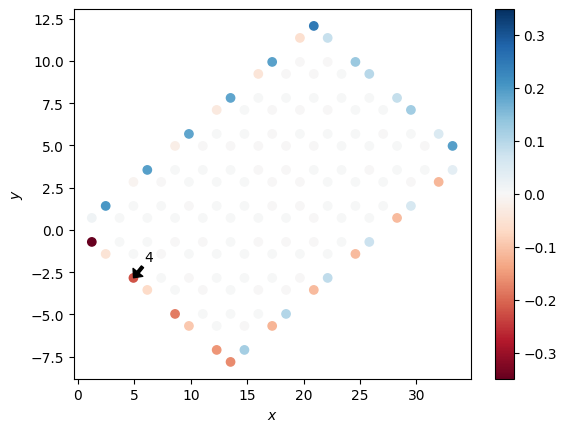

In [166]:
site = N0 

coupling = np.imag(RSE[N0//2, :])
vmax = np.max(np.abs(coupling))
vmin = -vmax

xyz = HamNN.xyz

fig, ax = plt.subplots()
sc = ax.scatter(xyz[:, 0], xyz[:, 1], c=coupling, vmin=vmin, vmax=vmax, cmap="RdBu")
ax.annotate(text=site, xy=(xyz[site, 0]+0.01, xyz[site, 1]+0.01), xytext=(xyz[site, 0] + 1, xyz[site, 1] + 1),
            arrowprops=dict(
                headwidth=9,
                headlength=5,
                width=2,
                color='k',
            )
)

ax.set(ylabel=r"$y$",
       xlabel=r"$x$")

fig.colorbar(sc)